# Education Efficiency Index — cross-country, PISA 2022

Country-level **Education Efficiency Index** built as the standardised residual of a log-linear regression of PISA 2022 scores on a small set of input drivers, all from official cross-country statistical sources.

## Drivers (per congress-paper guidance)

1. **Per-secondary-student spending** (USD PPP) — World Bank `SE.XPD.SECO.PC.ZS` × GDP per capita PPP.
2. **GDP per capita PPP** — World Bank `NY.GDP.PCAP.PP.CD`, 2022.
3. **Mean years of schooling** — UNDP HDR, 2022.
4. **Total education expenditure (% of GDP)** — World Bank `SE.XPD.TOTL.GD.ZS`, latest available.
5. **Government Effectiveness** — World Bank Worldwide Governance Indicators `GOV_WGI_GE.EST`, latest available — proxy for the institutional environment (Acemoglu *et al.* line of research).

## Production function (preferred specification)

$$\ln(\text{PISA}_i) = \theta\,\ln(\text{Spend}_i) + \beta\,\ln(\text{GDP}_i) + \gamma\,\ln(\text{MYS}_i) + \eta\,\text{GovEff}_i + \delta + \varepsilon_i$$

Estimated by **OLS** with HC1-robust standard errors. The notebook also reports a **2SLS robustness check** with lagged spending as instrument for current spending. The conference paper presents the index as **descriptive/predictive**; causal identification is left for follow-up work.

## Efficiency Index

$$\text{EI}_i = \frac{\hat\varepsilon_i - \bar{\hat\varepsilon}}{\hat\sigma_{\hat\varepsilon}}$$

Z-score directly. Positive ⇒ country produces more PISA points than its measurable inputs predict; negative ⇒ underperformance.

In [1]:
import json
import numpy as np
import pandas as pd
import statsmodels.api as sm
from linearmodels.iv import IV2SLS
import matplotlib.pyplot as plt

DATA = 'data'

## 1. Load all data sources

In [2]:
def wb_json(path, name):
    raw = json.load(open(path))[1]
    rows = [{'geo': r['countryiso3code'], 'year': int(r['date']), name: r['value']}
            for r in raw if r.get('countryiso3code') and r.get('value') is not None]
    return pd.DataFrame(rows)

def latest(df):
    return df.sort_values('year').groupby('geo').last().reset_index()

seco        = latest(wb_json(f'{DATA}/_wb_xpd_seco.json',     'spend_pct'))
seco_lag    = latest(wb_json(f'{DATA}/_wb_xpd_seco_lag.json', 'spend_pct_lag')).rename(columns={'year':'year_lag'})
xpd_total   = latest(wb_json(f'{DATA}/_wb_xpd_totl_gdp.json', 'xpd_pct_gdp')).rename(columns={'year':'xpd_year'})
gov_eff_raw = latest(wb_json(f'{DATA}/_wb_wgi_ge.json',       'gov_eff')).rename(columns={'year':'gov_eff_year'})

gdp_raw = pd.read_csv(f'{DATA}/API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_216039.csv', skiprows=4)
gdp = (gdp_raw[['Country Code', 'Country Name', '2022']]
       .rename(columns={'Country Code': 'geo', 'Country Name': 'name', '2022': 'gdp_per_capita'})
       .dropna())
gdp['geo'] = gdp['geo'].str.upper()

pisa = pd.read_csv(f'{DATA}/pisa_master_dataset.csv')
pisa = pisa[pisa['year'] == 2022][['geo', 'pisa_score']].copy()
pisa['geo'] = pisa['geo'].str.upper()

hdr = pd.read_excel(f'{DATA}/hdr-data.xlsx')
hdr.columns = hdr.columns.str.strip()
hdr['year'] = pd.to_numeric(hdr['year'], errors='coerce')
mys = (hdr[hdr['year'] == 2022][['countryIsoCode', 'value']]
          .rename(columns={'countryIsoCode': 'geo', 'value': 'years_schooling'}))
mys['geo'] = mys['geo'].str.upper()

for label, dfx in [('WB secondary spending (latest)', seco),
                   ('WB secondary spending (lagged)', seco_lag),
                   ('WB total ed exp (% GDP)', xpd_total),
                   ('WB Govt Effectiveness', gov_eff_raw),
                   ('WB GDP per capita PPP', gdp),
                   ('OECD PISA 2022', pisa),
                   ('UNDP HDR mean years schooling', mys)]:
    print(f'{label:38} {len(dfx):>3} countries')

WB secondary spending (latest)         121 countries
WB secondary spending (lagged)         165 countries
WB total ed exp (% GDP)                228 countries
WB Govt Effectiveness                  205 countries
WB GDP per capita PPP                  247 countries
OECD PISA 2022                          80 countries
UNDP HDR mean years schooling          204 countries


## 2. Build the analysis sample

In [3]:
df = (seco.merge(gdp, on='geo')
          .merge(pisa, on='geo')
          .merge(mys, on='geo')
          .merge(seco_lag,    on='geo', how='left')
          .merge(xpd_total[['geo', 'xpd_pct_gdp', 'xpd_year']], on='geo', how='left')
          .merge(gov_eff_raw[['geo', 'gov_eff', 'gov_eff_year']], on='geo', how='left'))

df['spend_per_student']     = df['spend_pct']     / 100 * df['gdp_per_capita']
df['spend_per_student_lag'] = df['spend_pct_lag'] / 100 * df['gdp_per_capita']
df = df.rename(columns={'year': 'spend_year'})

core = df.dropna(subset=['spend_per_student', 'pisa_score', 'gdp_per_capita',
                          'years_schooling', 'gov_eff']).reset_index(drop=True)
iv_sample = core.dropna(subset=['spend_per_student_lag']).reset_index(drop=True)

print(f'Core sample (preferred OLS): {len(core)} countries')
print(f'IV sample (2SLS robustness): {len(iv_sample)} countries')
core[['geo', 'name', 'pisa_score', 'spend_per_student', 'gdp_per_capita',
       'years_schooling', 'gov_eff', 'xpd_pct_gdp']].head()

Core sample (preferred OLS): 57 countries
IV sample (2SLS robustness): 55 countries


,geo,name,pisa_score,spend_per_student,gdp_per_capita,years_schooling,gov_eff,xpd_pct_gdp
0,ALB,Albania,367.333333,1551.429573,19446.225246,10.175311,0.293429,3.09153
1,ARG,Argentina,395.000000,6103.814010,29597.693843,11.184582,0.061473,5.00324
2,AUS,Australia,497.333333,9868.506991,65871.771516,12.870000,1.781813,5.05915
3,AUT,Austria,486.000000,19608.037313,70734.942565,12.361465,1.579057,5.27749
4,BRA,Brazil,397.333333,4278.800775,19876.853353,8.425372,-0.266622,5.61921


## 3. Specification search

Following Bianchi (2026, supervisor’s recommendation), the candidate drivers are spending, GDP per capita, mean years of schooling, total education expenditure as a percentage of GDP, and the institutional environment proxied by the World Bank's Government Effectiveness indicator.

In [4]:
for col, src in [('ln_pisa', 'pisa_score'), ('ln_spend', 'spend_per_student'),
                  ('ln_gdp', 'gdp_per_capita'), ('ln_school', 'years_schooling')]:
    core[col] = np.log(core[src])

specs = [
    ('M1: spend + gdp + school',          ['ln_spend', 'ln_gdp', 'ln_school']),
    ('M2: + total ed exp (% GDP)',        ['ln_spend', 'ln_gdp', 'ln_school', 'xpd_pct_gdp']),
    ('M3: + governance',                  ['ln_spend', 'ln_gdp', 'ln_school', 'gov_eff']),
    ('M4: full',                          ['ln_spend', 'ln_gdp', 'ln_school', 'xpd_pct_gdp', 'gov_eff']),
]

rows = []
for name, cols in specs:
    sub = core.dropna(subset=cols)
    X = sm.add_constant(sub[cols])
    m = sm.OLS(sub['ln_pisa'], X).fit(cov_type='HC1')
    rows.append({'spec': name, 'R²': round(m.rsquared, 3),
                 'adj R²': round(m.rsquared_adj, 3), 'N': len(sub),
                 'AIC': round(m.aic, 1), 'BIC': round(m.bic, 1)})
pd.DataFrame(rows).set_index('spec')

,R²,adj R²,N,AIC,BIC
spec,,,,,
M1: spend + gdp + school,0.720,0.704,57,-148.8,-140.7
M2: + total ed exp (% GDP),0.729,0.708,56,-145.0,-134.8
M3: + governance,0.735,0.715,57,-150.0,-139.8
M4: full,0.744,0.718,56,-146.1,-133.9


## 4. Preferred OLS specification: M3 (spend + GDP + MYS + governance)

M3 maximises adjusted R² and matches the supervisor's emphasis on institutions, while keeping the model parsimonious. Total education expenditure as a percentage of GDP (`xpd_pct_gdp`) is not statistically significant in any specification and is dropped.

In [5]:
X_ols = sm.add_constant(core[['ln_spend', 'ln_gdp', 'ln_school', 'gov_eff']])
ols   = sm.OLS(core['ln_pisa'], X_ols).fit(cov_type='HC1')
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                ln_pisa   R-squared:                       0.735
Model:                            OLS   Adj. R-squared:                  0.715
Method:                 Least Squares   F-statistic:                     41.50
Date:                Wed, 06 May 2026   Prob (F-statistic):           1.36e-15
Time:                        14:02:07   Log-Likelihood:                 80.019
No. Observations:                  57   AIC:                            -150.0
Df Residuals:                      52   BIC:                            -139.8
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.9519      0.251     19.700      0.0

## 5. 2SLS robustness check

Lagged spending (2005–2014, latest available) instruments current spending.

In [6]:
for col, src in [('ln_pisa', 'pisa_score'), ('ln_spend', 'spend_per_student'),
                  ('ln_gdp', 'gdp_per_capita'), ('ln_school', 'years_schooling'),
                  ('ln_spend_lag', 'spend_per_student_lag')]:
    iv_sample[col] = np.log(iv_sample[src])

iv_model = IV2SLS.from_formula(
    'ln_pisa ~ 1 + ln_gdp + ln_school + gov_eff + [ln_spend ~ ln_spend_lag]',
    data=iv_sample,
)
iv_res = iv_model.fit(cov_type='robust')
print(iv_res)
print()
print('First-stage diagnostics:')
print(iv_res.first_stage.diagnostics)

                          IV-2SLS Estimation Summary                          
Dep. Variable:                ln_pisa   R-squared:                      0.7345
Estimator:                    IV-2SLS   Adj. R-squared:                 0.7133
No. Observations:                  55   F-statistic:                    170.34
Date:                Wed, May 06 2026   P-value (F-stat)                0.0000
Time:                        14:02:07   Distribution:                  chi2(4)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      4.9852     0.2614     19.072     0.0000      4.4729      5.4975
ln_gdp         0.0411     0.0456     0.9012     0.36

## 6. Coefficient comparison

In [7]:
ols_iv_X = sm.add_constant(iv_sample[['ln_spend', 'ln_gdp', 'ln_school', 'gov_eff']])
ols_iv = sm.OLS(iv_sample['ln_pisa'], ols_iv_X).fit(cov_type='HC1')

comparison = pd.DataFrame({
    'OLS (full sample)': [ols.params['ln_spend'],   ols.params['ln_gdp'],   ols.params['ln_school'],   ols.params['gov_eff'],   ols.rsquared,   len(core)],
    'OLS (IV sample)':   [ols_iv.params['ln_spend'], ols_iv.params['ln_gdp'], ols_iv.params['ln_school'], ols_iv.params['gov_eff'], ols_iv.rsquared, len(iv_sample)],
    '2SLS':              [iv_res.params['ln_spend'], iv_res.params['ln_gdp'], iv_res.params['ln_school'], iv_res.params['gov_eff'], iv_res.rsquared, len(iv_sample)],
}, index=['β_spend', 'β_GDP', 'β_school', 'β_GovEff', 'R²', 'N']).round(3)
comparison

,OLS (full sample),OLS (IV sample),2SLS
β_spend,0.027,0.023,0.041
β_GDP,0.052,0.060,0.041
β_school,0.136,0.137,0.119
β_GovEff,0.038,0.035,0.035
R²,0.735,0.736,0.735
N,57.000,55.000,55.000


## 7. Compute the Education Efficiency Index

Predictions come from the **preferred OLS specification (M3)**. The 2SLS estimates are kept as a robustness check in the methodology note but not used to score countries — Bianchi's guidance was to keep the methodology presentable for the conference and pursue causal identification later.

In [8]:
core['ln_pisa_pred'] = ols.predict(X_ols)
core['pisa_pred']    = np.exp(core['ln_pisa_pred'])
core['residual']     = core['ln_pisa'] - core['ln_pisa_pred']
core['efficiency_z'] = (core['residual'] - core['residual'].mean()) / core['residual'].std()
core['pisa_per_1k_usd'] = core['pisa_score'] / (core['spend_per_student'] / 1000)

out_cols = ['geo', 'name', 'pisa_score', 'pisa_pred',
            'spend_per_student', 'spend_year',
            'gdp_per_capita', 'years_schooling',
            'xpd_pct_gdp', 'gov_eff',
            'pisa_per_1k_usd', 'residual', 'efficiency_z']
core[out_cols].to_csv(f'{DATA}/efficiency_index.csv', index=False)
print(f'Saved {DATA}/efficiency_index.csv ({len(core)} countries)')
print()
print('Top 10:')
print(core.sort_values('efficiency_z', ascending=False).head(10)[
    ['name', 'pisa_score', 'pisa_pred', 'gov_eff', 'efficiency_z']].to_string(index=False))
print()
print('Bottom 10:')
print(core.sort_values('efficiency_z').head(10)[
    ['name', 'pisa_score', 'pisa_pred', 'gov_eff', 'efficiency_z']].to_string(index=False))

Saved data/efficiency_index.csv (57 countries)

Top 10:
                name  pisa_score  pisa_pred   gov_eff  efficiency_z
             Turkiye  461.666667 413.355309 -0.114085      1.843211
             Ukraine  439.666667 395.854517 -0.580338      1.750405
               Japan  533.000000 483.430409  1.988388      1.627741
         Korea, Rep.  523.333333 479.732107  1.495591      1.450595
             Estonia  515.666667 473.510631  1.267895      1.422171
           Guatemala  363.666667 339.133559 -0.862881      1.164663
              Poland  492.333333 460.177660  0.634104      1.126304
Hong Kong SAR, China  520.000000 486.418703  1.537420      1.113225
            Portugal  477.666667 448.105629  0.965849      1.065286
              Serbia  442.333333 416.141656  0.103544      1.017826

Bottom 10:
              name  pisa_score  pisa_pred  gov_eff  efficiency_z
            Cyprus  403.333333 476.377199 0.931477     -2.775543
Dominican Republic  350.000000 404.920447 0.045792    

## 8. Visual diagnostics

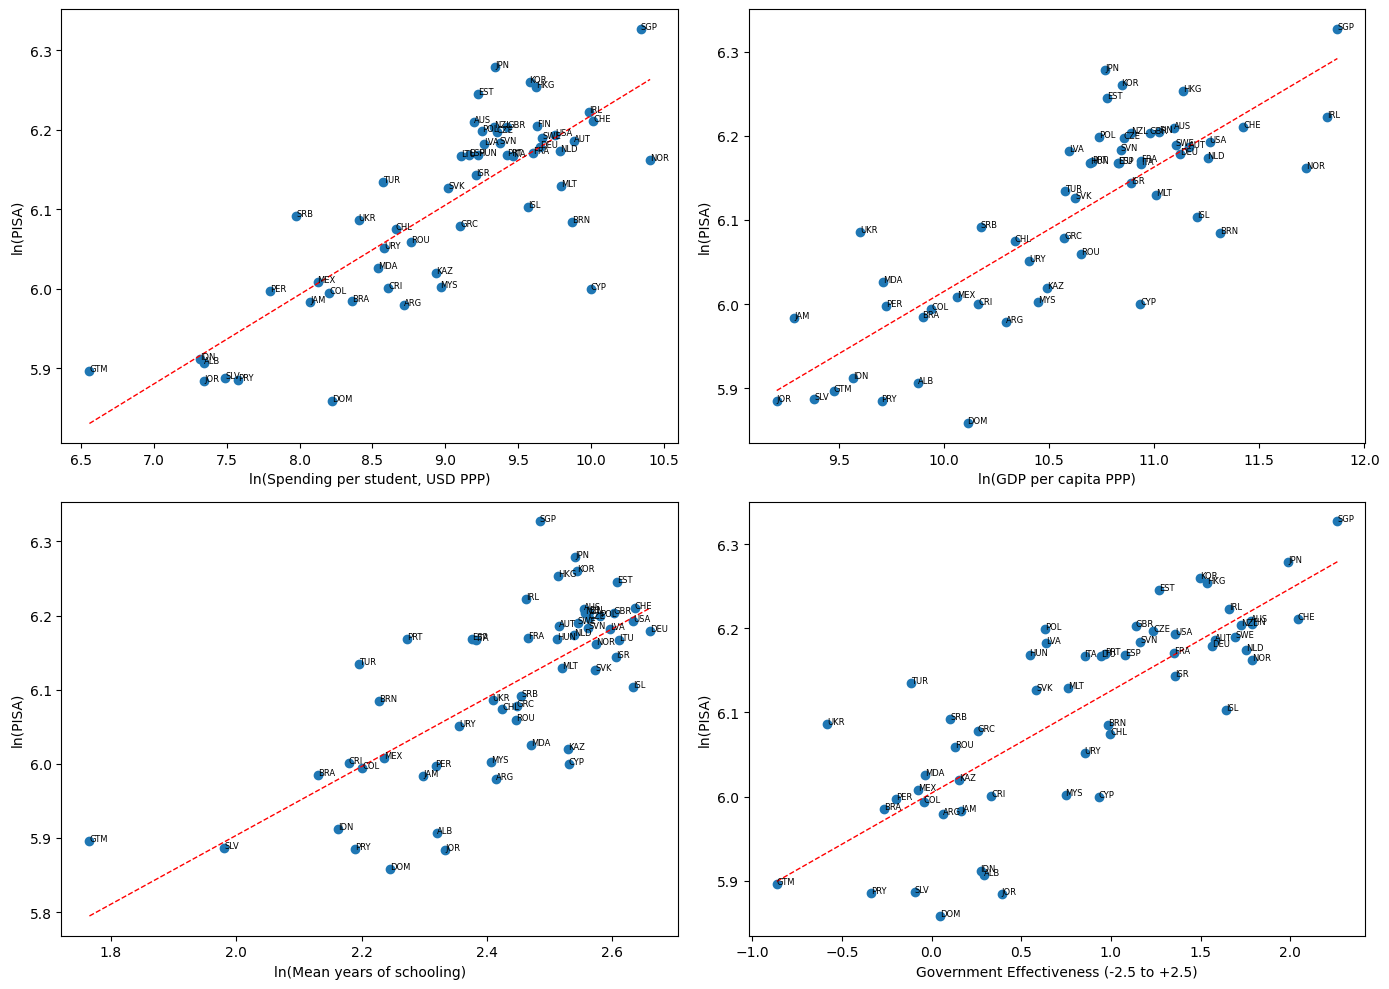

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, x_col, label in [
    (axes[0, 0], 'ln_spend',  'ln(Spending per student, USD PPP)'),
    (axes[0, 1], 'ln_gdp',    'ln(GDP per capita PPP)'),
    (axes[1, 0], 'ln_school', 'ln(Mean years of schooling)'),
    (axes[1, 1], 'gov_eff',   'Government Effectiveness (-2.5 to +2.5)'),
]:
    ax.scatter(core[x_col], core['ln_pisa'])
    for _, r in core.iterrows():
        ax.annotate(r['geo'], (r[x_col], r['ln_pisa']), fontsize=6)
    ax.set(xlabel=label, ylabel='ln(PISA)')
    z = np.polyfit(core[x_col], core['ln_pisa'], 1)
    xs = np.linspace(core[x_col].min(), core[x_col].max(), 50)
    ax.plot(xs, np.polyval(z, xs), color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()